In [2]:

import pandas as pd
import numpy as np
import kagglehub
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score,
    recall_score, f1_score, matthews_corrcoef
)
import os
import matplotlib.pyplot as plt
import joblib


In [3]:
import kagglehub
path = kagglehub.dataset_download("iabhishekofficial/mobile-price-classification")

100%|██████████| 70.6k/70.6k [00:00<00:00, 40.1MB/s]

Extracting files...


In [4]:
df = pd.read_csv(os.path.join(path, "train.csv"))

In [5]:
print(df.shape)
print(df.isnull().sum())

(2000, 21)
battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64


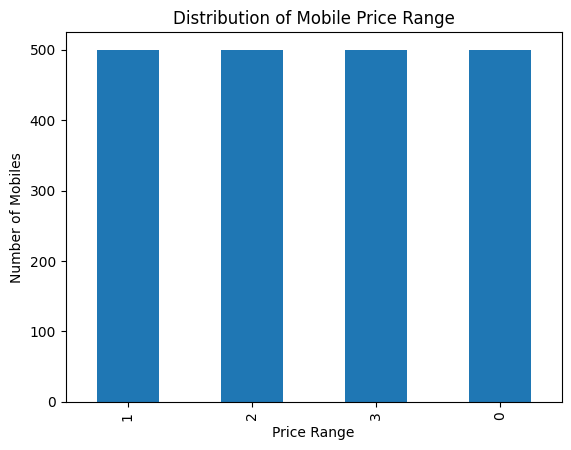

In [6]:
ax = df['price_range'].value_counts().plot(kind='bar')

ax.set_xlabel("Price Range")
ax.set_ylabel("Number of Mobiles")
ax.set_title("Distribution of Mobile Price Range");


There are no missing values. Classes are equally distributed. There are 2000 records and has 20 features + 1 target column.

In [7]:
X = df.drop("price_range", axis=1)
y = df["price_range"]


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(f"X_train shape:{X_train.shape}")
print(f"X_test shape:{X_test.shape}")
print(f"y_train shape:{y_train.shape}")
print(f"y_test shape:{y_test.shape}")

X_train shape:(1600, 20)
X_test shape:(400, 20)
y_train shape:(1600,)
y_test shape:(400,)


In [9]:
# Save test data for Streamlit app
test_data = X_test.copy()
test_data['price_range'] = y_test
test_data.to_csv('test_data.csv', index=False)



In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:

os.makedirs("models", exist_ok=True)
os.makedirs("data", exist_ok=True)


In [12]:
joblib.dump(scaler, "models/scaler.pkl")

['models/scaler.pkl']

In [13]:
# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42,max_depth=5 ),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,max_depth=4
    ),
    "XGBoost": XGBClassifier(
        objective="multi:softprob",
        num_class=4,
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        eval_metric="mlogloss",
        random_state=42
    )
}


In [14]:
# Training + Evaluation
results = []

for name, model in models.items():

    if name in ["Logistic Regression", "KNN", "Naive Bayes"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob, multi_class="ovr"),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1": f1_score(y_test, y_pred, average="weighted"),
        "MCC": matthews_corrcoef(y_test, y_pred)
    })

    joblib.dump(
        model,
        f"models/{name.lower().replace(' ', '_')}.pkl"
    )

In [15]:
# Results output

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy       AUC  Precision  Recall        F1  \
0  Logistic Regression    0.9650  0.998667   0.965045  0.9650  0.964986   
1        Decision Tree    0.8300  0.945950   0.834941  0.8300  0.831660   
2                  KNN    0.5000  0.769750   0.521130  0.5000  0.505355   
3          Naive Bayes    0.8100  0.950558   0.811326  0.8100  0.810458   
4        Random Forest    0.8350  0.950833   0.830228  0.8350  0.829901   
5              XGBoost    0.9225  0.993700   0.922631  0.9225  0.922482   

        MCC  
0  0.953357  
1  0.773856  
2  0.334993  
3  0.746804  
4  0.781682  
5  0.896719  


In [16]:
test_df = X_test.copy()
test_df["price_range"] = y_test.values
test_df.to_csv("data/test_data.csv", index=False)

In [17]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [18]:
!cp -r data /content/drive/MyDrive/
!cp -r models /content/drive/MyDrive/
